Compiling model...
'compile' took 0.000497 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [4.37e+01, 1.68e-03, 6.74e-03]    [4.94e+01, 1.68e-03, 6.74e-03]    [9.76e-01]    


/home/hridoy/miniconda3/envs/torch-env/lib/python3.10/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1000      [4.22e-04, 3.41e-09, 5.79e-08]    [5.13e-04, 3.39e-09, 5.78e-08]    [2.72e-04]    
2000      [6.21e-05, 5.86e-10, 4.16e-09]    [1.38e-04, 5.92e-10, 4.13e-09]    [1.32e-04]    
3000      [4.88e-05, 4.33e-06, 1.85e-05]    [7.83e-05, 4.33e-06, 1.85e-05]    [2.23e-03]    
4000      [1.50e-05, 2.67e-10, 4.35e-10]    [5.26e-05, 2.70e-10, 4.40e-10]    [6.55e-05]    
5000      [1.30e-05, 1.11e-07, 4.07e-07]    [4.10e-05, 1.10e-07, 4.08e-07]    [3.15e-04]    
6000      [1.58e-05, 3.99e-07, 7.95e-07]    [4.00e-05, 3.98e-07, 7.95e-07]    [6.29e-04]    
7000      [6.89e-06, 1.06e-10, 1.75e-10]    [2.93e-05, 1.11e-10, 1.66e-10]    [4.52e-05]    
8000      [4.80e-06, 3.12e-10, 1.20e-10]    [2.42e-05, 3.03e-10, 1.20e-10]    [3.26e-05]    
9000      [1.12e-05, 2.78e-07, 1.44e-06]    [3.52e-05, 2.78e-07, 1.44e-06]    [5.12e-04]    
10000     [2.53e-06, 1.27e-11, 1.13e-09]    [1.82e-05, 1.18e-11, 1.14e-09]    [6.47e-05]    

Best model at step 10000:
  train loss: 2.53e-06
  test loss: 1.82e-0

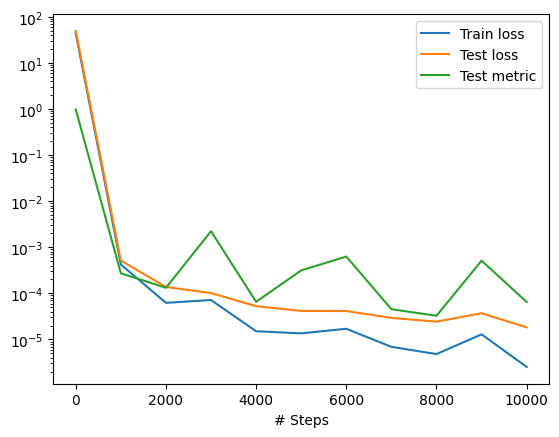

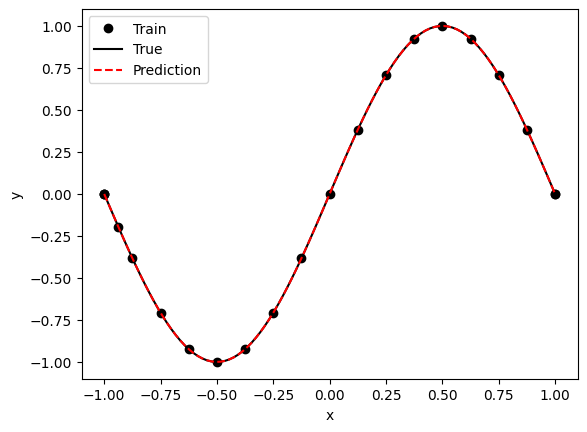

In [6]:
import deepxde as dde
import numpy as np
import torch


def pde(x, y):
    dy_xx = dde.grad.hessian(y, x)
    return - dy_xx - np.pi**2 * torch.sin(np.pi * x)


def boundary_l(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], -1)


def boundary_r(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], 1)


def func(x):
    return np.sin(np.pi * x)


geom = dde.geometry.Interval(-1, 1)
bc_l = dde.icbc.DirichletBC(geom, func, boundary_l)
bc_r = dde.icbc.PeriodicBC(geom, 0, boundary_r)
data = dde.data.PDE(geom, pde, [bc_l, bc_r], 16, 2, solution=func, num_test=100)

layer_size = [1] + [50] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=10000)

dde.saveplot(losshistory, train_state, issave=False, isplot=True)